In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

data = pd.read_csv('/Users/shreyashnivagune/Documents/NHS_Intelligence/rtt_waiting_times_mar26.csv', encoding='latin-1')

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print("\nColumn names:")
print(data.columns.tolist())


Rows: 183400
Columns: 121

Column names:
['Period', 'Provider Parent Org Code', 'Provider Parent Name', 'Provider Org Code', 'Provider Org Name', 'Commissioner Parent Org Code', 'Commissioner Parent Name', 'Commissioner Org Code', 'Commissioner Org Name', 'RTT Part Type', 'RTT Part Description', 'Treatment Function Code', 'Treatment Function Name', 'Gt 00 To 01 Weeks SUM 1', 'Gt 01 To 02 Weeks SUM 1', 'Gt 02 To 03 Weeks SUM 1', 'Gt 03 To 04 Weeks SUM 1', 'Gt 04 To 05 Weeks SUM 1', 'Gt 05 To 06 Weeks SUM 1', 'Gt 06 To 07 Weeks SUM 1', 'Gt 07 To 08 Weeks SUM 1', 'Gt 08 To 09 Weeks SUM 1', 'Gt 09 To 10 Weeks SUM 1', 'Gt 10 To 11 Weeks SUM 1', 'Gt 11 To 12 Weeks SUM 1', 'Gt 12 To 13 Weeks SUM 1', 'Gt 13 To 14 Weeks SUM 1', 'Gt 14 To 15 Weeks SUM 1', 'Gt 15 To 16 Weeks SUM 1', 'Gt 16 To 17 Weeks SUM 1', 'Gt 17 To 18 Weeks SUM 1', 'Gt 18 To 19 Weeks SUM 1', 'Gt 19 To 20 Weeks SUM 1', 'Gt 20 To 21 Weeks SUM 1', 'Gt 21 To 22 Weeks SUM 1', 'Gt 22 To 23 Weeks SUM 1', 'Gt 23 To 24 Weeks SUM 1', '

In [4]:
# Check date range
print("Date range:")
print(data['Period'].unique())

print("\nRTT Part Types:")
print(data['RTT Part Type'].unique())

print("\nNumber of unique providers:")
print(data['Provider Org Name'].nunique())

print("\nNumber of unique specialties:")
print(data['Treatment Function Name'].nunique())

print("\nSample of data:")
data.head(3)

Date range:
['RTT-March-2026']

RTT Part Types:
['Part_2' 'Part_3' 'Part_1A' 'Part_1B' 'Part_2A']

Number of unique providers:
532

Number of unique specialties:
24

Sample of data:


,Period,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,...,Gt 98 To 99 Weeks SUM 1,Gt 99 To 100 Weeks SUM 1,Gt 100 To 101 Weeks SUM 1,Gt 101 To 102 Weeks SUM 1,Gt 102 To 103 Weeks SUM 1,Gt 103 To 104 Weeks SUM 1,Gt 104 Weeks SUM 1,Total,Patients with unknown clock start date,Total All
0,RTT-March-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
1,RTT-March-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
2,RTT-March-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2


In [6]:
# Filter to incomplete pathways only (active waiting list)
incomplete = data[data['RTT Part Type'] == 'Part_2'].copy()

print("Incomplete pathway rows:", len(incomplete))

# Define the wait band columns
wait_cols = [col for col in data.columns if col.startswith('Gt')]
print("Wait band columns:", len(wait_cols))

# Convert wait band columns to numeric
incomplete[wait_cols] = incomplete[wait_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
incomplete['Total'] = pd.to_numeric(incomplete['Total'], errors='coerce').fillna(0)

# Helper functions
def _is_over_18(col_name):
    try:
        week_num = int(col_name.split('Gt ')[1].split(' To')[0])
        return week_num >= 18
    except:
        return False

def _is_over_52(col_name):
    try:
        week_num = int(col_name.split('Gt ')[1].split(' To')[0])
        return week_num >= 52
    except:
        return False

# Derived metrics
incomplete['waiting_over_18_weeks'] = incomplete[[c for c in wait_cols if _is_over_18(c)]].sum(axis=1)
incomplete['waiting_over_52_weeks'] = incomplete[[c for c in wait_cols if _is_over_52(c)]].sum(axis=1)
incomplete['waiting_over_104_weeks'] = pd.to_numeric(incomplete['Gt 104 Weeks SUM 1'], errors='coerce').fillna(0)

print("\nSample totals:")
print(incomplete[['Provider Org Name', 'Treatment Function Name', 'Total',
                   'waiting_over_18_weeks', 'waiting_over_52_weeks']].head(10))

Incomplete pathway rows: 63547
Wait band columns: 105

Sample totals:
    Provider Org Name         Treatment Function Name  Total  \
0   BUCKSHAW HOSPITAL         General Surgery Service    0.0   
1   BUCKSHAW HOSPITAL                 Urology Service    0.0   
2   BUCKSHAW HOSPITAL                           Total    0.0   
5   BUCKSHAW HOSPITAL         General Surgery Service    0.0   
6   BUCKSHAW HOSPITAL                           Total    0.0   
9   BUCKSHAW HOSPITAL                 Urology Service    0.0   
10  BUCKSHAW HOSPITAL  Trauma and Orthopaedic Service    0.0   
11  BUCKSHAW HOSPITAL                           Total    0.0   
17  BUCKSHAW HOSPITAL         General Surgery Service    0.0   
18  BUCKSHAW HOSPITAL                 Urology Service    0.0   

    waiting_over_18_weeks  waiting_over_52_weeks  
0                     0.0                    0.0  
1                     1.0                    0.0  
2                     1.0                    0.0  
5                    

/var/folders/8s/hd18skcd1q900x7_ccxjq0r80000gn/T/ipykernel_77230/1653834120.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  incomplete['waiting_over_18_weeks'] = incomplete[[c for c in wait_cols if _is_over_18(c)]].sum(axis=1)
/var/folders/8s/hd18skcd1q900x7_ccxjq0r80000gn/T/ipykernel_77230/1653834120.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  incomplete['waiting_over_52_weeks'] = incomplete[[c for c in wait_cols if _is_over_52(c)]].sum(axis=1)
/var/folders/8s/hd18skcd1q900x7_ccxjq0r80000gn/T/ipykernel_77230/16538

In [7]:
# Fix the fragmentation warning
incomplete = incomplete.copy()

# Remove "Total" rows - these are subtotals we don't need
incomplete = incomplete[incomplete['Treatment Function Name'] != 'Total']

print("Rows after removing subtotals:", len(incomplete))

# National summary
print("\n--- NATIONAL PICTURE ---")
print(f"Total patients waiting:        {incomplete['Total'].sum():,.0f}")
print(f"Waiting over 18 weeks:         {incomplete['waiting_over_18_weeks'].sum():,.0f}")
print(f"Waiting over 52 weeks:         {incomplete['waiting_over_52_weeks'].sum():,.0f}")
print(f"Waiting over 104 weeks:        {incomplete['waiting_over_104_weeks'].sum():,.0f}")

pct_over_18 = incomplete['waiting_over_18_weeks'].sum() / incomplete['Total'].sum() * 100
print(f"\n% waiting over 18 weeks:       {pct_over_18:.1f}%")

# Top 10 specialties by total waiting
print("\n--- TOP 10 SPECIALTIES BY WAITING LIST SIZE ---")
by_specialty = incomplete.groupby('Treatment Function Name')['Total'].sum().sort_values(ascending=False).head(10)
print(by_specialty.to_string())

Rows after removing subtotals: 50645

--- NATIONAL PICTURE ---
Total patients waiting:        0
Waiting over 18 weeks:         2,448,389
Waiting over 52 weeks:         95,325
Waiting over 104 weeks:        499

% waiting over 18 weeks:       inf%

--- TOP 10 SPECIALTIES BY WAITING LIST SIZE ---
Treatment Function Name
Cardiology Service                0.0
Oral Surgery Service              0.0
Trauma and Orthopaedic Service    0.0
Rheumatology Service              0.0
Respiratory Medicine Service      0.0
Plastic Surgery Service           0.0
Other - Surgical Services         0.0
Other - Paediatric Services       0.0
Other - Other Services            0.0
Other - Mental Health Services    0.0


/var/folders/8s/hd18skcd1q900x7_ccxjq0r80000gn/T/ipykernel_77230/3810957343.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  pct_over_18 = incomplete['waiting_over_18_weeks'].sum() / incomplete['Total'].sum() * 100


In [8]:
# Recalculate Total from wait band columns directly
incomplete['Total'] = incomplete[wait_cols].sum(axis=1)

print("--- NATIONAL PICTURE ---")
print(f"Total patients waiting:        {incomplete['Total'].sum():,.0f}")
print(f"Waiting over 18 weeks:         {incomplete['waiting_over_18_weeks'].sum():,.0f}")
print(f"Waiting over 52 weeks:         {incomplete['waiting_over_52_weeks'].sum():,.0f}")
print(f"Waiting over 104 weeks:        {incomplete['waiting_over_104_weeks'].sum():,.0f}")

pct_over_18 = incomplete['waiting_over_18_weeks'].sum() / incomplete['Total'].sum() * 100
print(f"\n% waiting over 18 weeks:       {pct_over_18:.1f}%")

# Top 10 specialties by total waiting
print("\n--- TOP 10 SPECIALTIES BY WAITING LIST SIZE ---")
by_specialty = incomplete.groupby('Treatment Function Name')['Total'].sum().sort_values(ascending=False).head(10)
print(by_specialty.to_string())

--- NATIONAL PICTURE ---
Total patients waiting:        7,045,510
Waiting over 18 weeks:         2,448,389
Waiting over 52 weeks:         95,325
Waiting over 104 weeks:        499

% waiting over 18 weeks:       34.8%

--- TOP 10 SPECIALTIES BY WAITING LIST SIZE ---
Treatment Function Name
Trauma and Orthopaedic Service    826172.0
Other - Medical Services          614175.0
Ophthalmology Service             603966.0
Ear Nose and Throat Service       580054.0
Gynaecology Service               555528.0
Other - Surgical Services         467771.0
Urology Service                   378188.0
General Surgery Service           376693.0
Cardiology Service                375773.0
Dermatology Service               372060.0


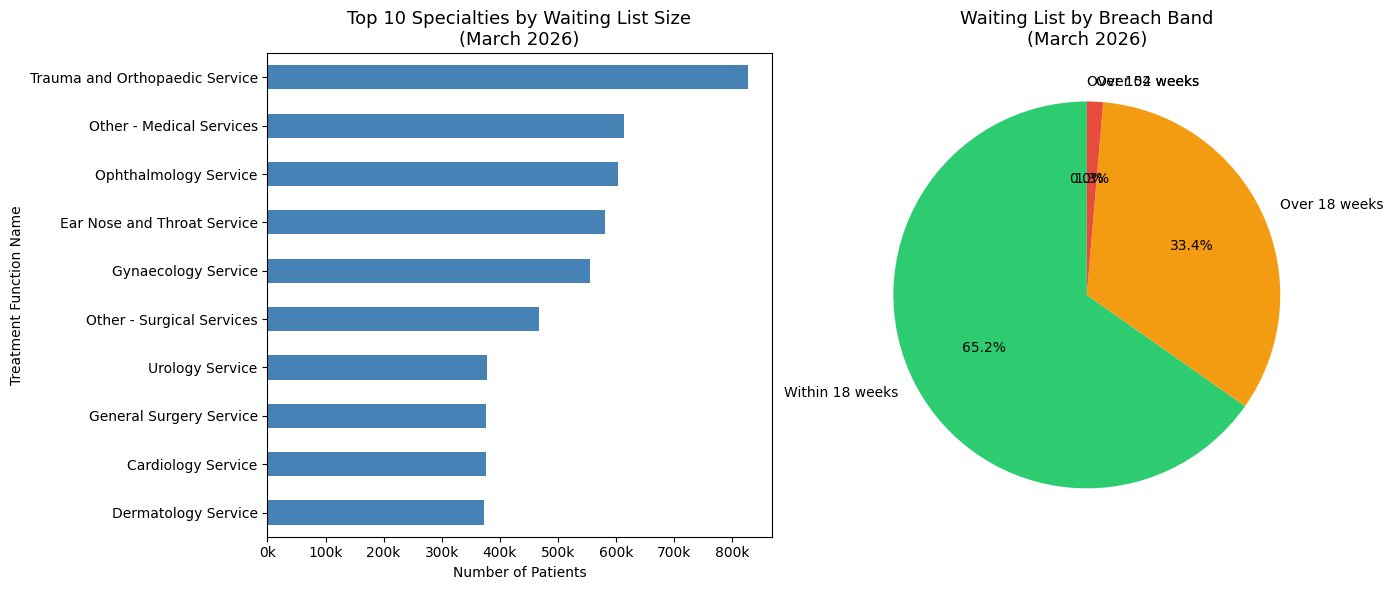

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Waiting list by specialty
by_specialty.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Specialties by Waiting List Size\n(March 2026)', fontsize=13)
axes[0].set_xlabel('Number of Patients')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Chart 2 - Breach summary
breach_data = {
    'Within 18 weeks': incomplete['Total'].sum() - incomplete['waiting_over_18_weeks'].sum(),
    'Over 18 weeks': incomplete['waiting_over_18_weeks'].sum() - incomplete['waiting_over_52_weeks'].sum(),
    'Over 52 weeks': incomplete['waiting_over_52_weeks'].sum() - incomplete['waiting_over_104_weeks'].sum(),
    'Over 104 weeks': incomplete['waiting_over_104_weeks'].sum()
}

colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e0000']
axes[1].pie(breach_data.values(), labels=breach_data.keys(), colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Waiting List by Breach Band\n(March 2026)', fontsize=13)

plt.tight_layout()
plt.savefig('../../docs/wait_band_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [10]:
# Select and rename key columns for the curated layer
curated = incomplete[[
    'Period',
    'Provider Parent Org Code',
    'Provider Parent Name', 
    'Provider Org Code',
    'Provider Org Name',
    'Commissioner Org Code',
    'Commissioner Org Name',
    'RTT Part Type',
    'RTT Part Description',
    'Treatment Function Code',
    'Treatment Function Name',
    'Total',
    'waiting_over_18_weeks',
    'waiting_over_52_weeks',
    'waiting_over_104_weeks'
] + wait_cols].copy()

# Clean column names
curated.columns = curated.columns.str.strip().str.lower().str.replace(' ', '_')

# Save to curated layer
curated.to_csv('../../data/curated/rtt_incomplete_curated.csv', index=False)

print("Saved to data/curated/rtt_incomplete_curated.csv")
print("Shape:", curated.shape)
print("\nColumns saved:")
print(curated.columns.tolist()[:20], "... +", len(curated.columns)-20, "wait band columns")

Saved to data/curated/rtt_incomplete_curated.csv
Shape: (50645, 120)

Columns saved:
['period', 'provider_parent_org_code', 'provider_parent_name', 'provider_org_code', 'provider_org_name', 'commissioner_org_code', 'commissioner_org_name', 'rtt_part_type', 'rtt_part_description', 'treatment_function_code', 'treatment_function_name', 'total', 'waiting_over_18_weeks', 'waiting_over_52_weeks', 'waiting_over_104_weeks', 'gt_00_to_01_weeks_sum_1', 'gt_01_to_02_weeks_sum_1', 'gt_02_to_03_weeks_sum_1', 'gt_03_to_04_weeks_sum_1', 'gt_04_to_05_weeks_sum_1'] ... + 100 wait band columns


In [14]:
# Trust level breach risk summary
trust_summary = curated.groupby(['provider_parent_name', 'provider_org_name']).agg(
    total_waiting = ('total', 'sum'),
    over_18_weeks = ('waiting_over_18_weeks', 'sum'),
    over_52_weeks = ('waiting_over_52_weeks', 'sum'),
    over_104_weeks = ('waiting_over_104_weeks', 'sum')
).reset_index()

# Breach rate
trust_summary['breach_rate_pct'] = (trust_summary['over_18_weeks'] / trust_summary['total_waiting'] * 100).round(1)

# Remove trusts with tiny lists (under 100 patients)
trust_summary = trust_summary[trust_summary['total_waiting'] >= 100]

# Sort by breach rate
trust_summary = trust_summary.sort_values('breach_rate_pct', ascending=False)

print("Trusts analysed:", len(trust_summary))
print("\nTop 10 trusts by breach rate:")
print(trust_summary[['provider_org_name', 'total_waiting', 'over_18_weeks', 'breach_rate_pct']].head(10).to_string())

print("\nBottom 10 trusts (best performing):")
print(trust_summary[['provider_org_name', 'total_waiting', 'over_18_weeks', 'breach_rate_pct']].tail(10).to_string())

Trusts analysed: 477

Top 10 trusts by breach rate:
                                        provider_org_name  total_waiting  over_18_weeks  breach_rate_pct
212                            PIONEER HEALTHCARE LIMITED          715.0          633.0             88.5
222                            SPIRE SOUTHAMPTON HOSPITAL          352.0          268.0             76.1
209                      NUFFIELD HEALTH, WESSEX HOSPITAL          610.0          438.0             71.8
36                                           MODALITY LLP          264.0          168.0             63.6
78   CAMBRIDGESHIRE AND PETERBOROUGH NHS FOUNDATION TRUST          196.0          123.0             62.8
359         NUFFIELD HEALTH, NEWCASTLE UPON TYNE HOSPITAL          518.0          297.0             57.3
221                             SPIRE PORTSMOUTH HOSPITAL          460.0          258.0             56.1
79                                   FITZWILLIAM HOSPITAL         6880.0         3835.0             55.7
493

In [15]:
# Specialty level breach risk
specialty_summary = curated.groupby('treatment_function_name').agg(
    total_waiting = ('total', 'sum'),
    over_18_weeks = ('waiting_over_18_weeks', 'sum'),
    over_52_weeks = ('waiting_over_52_weeks', 'sum'),
    over_104_weeks = ('waiting_over_104_weeks', 'sum')
).reset_index()

specialty_summary['breach_rate_pct'] = (specialty_summary['over_18_weeks'] / specialty_summary['total_waiting'] * 100).round(1)
specialty_summary = specialty_summary.sort_values('breach_rate_pct', ascending=False)

print("--- BREACH RATE BY SPECIALTY ---")
print(specialty_summary[['treatment_function_name', 'total_waiting', 'over_18_weeks', 'breach_rate_pct']].to_string())

# Save both summaries
trust_summary.to_csv('../../data/curated/trust_breach_summary.csv', index=False)
specialty_summary.to_csv('../../data/curated/specialty_breach_summary.csv', index=False)

print("\nBoth summaries saved to data/curated/")

--- BREACH RATE BY SPECIALTY ---
              treatment_function_name  total_waiting  over_18_weeks  breach_rate_pct
12               Oral Surgery Service       320612.0       142507.0             44.4
18            Plastic Surgery Service       101370.0        43984.0             43.4
3         Ear Nose and Throat Service       580054.0       241215.0             41.6
21     Trauma and Orthopaedic Service       826172.0       337724.0             40.9
9                   Neurology Service       208673.0        82301.0             39.4
8                 Gynaecology Service       555528.0       217579.0             39.2
10              Neurosurgical Service        56423.0        21323.0             37.8
7             General Surgery Service       376693.0       139676.0             37.1
2                 Dermatology Service       372060.0       130062.0             35.0
17          Other - Surgical Services       467771.0       158662.0             33.9
22                    Urology Se

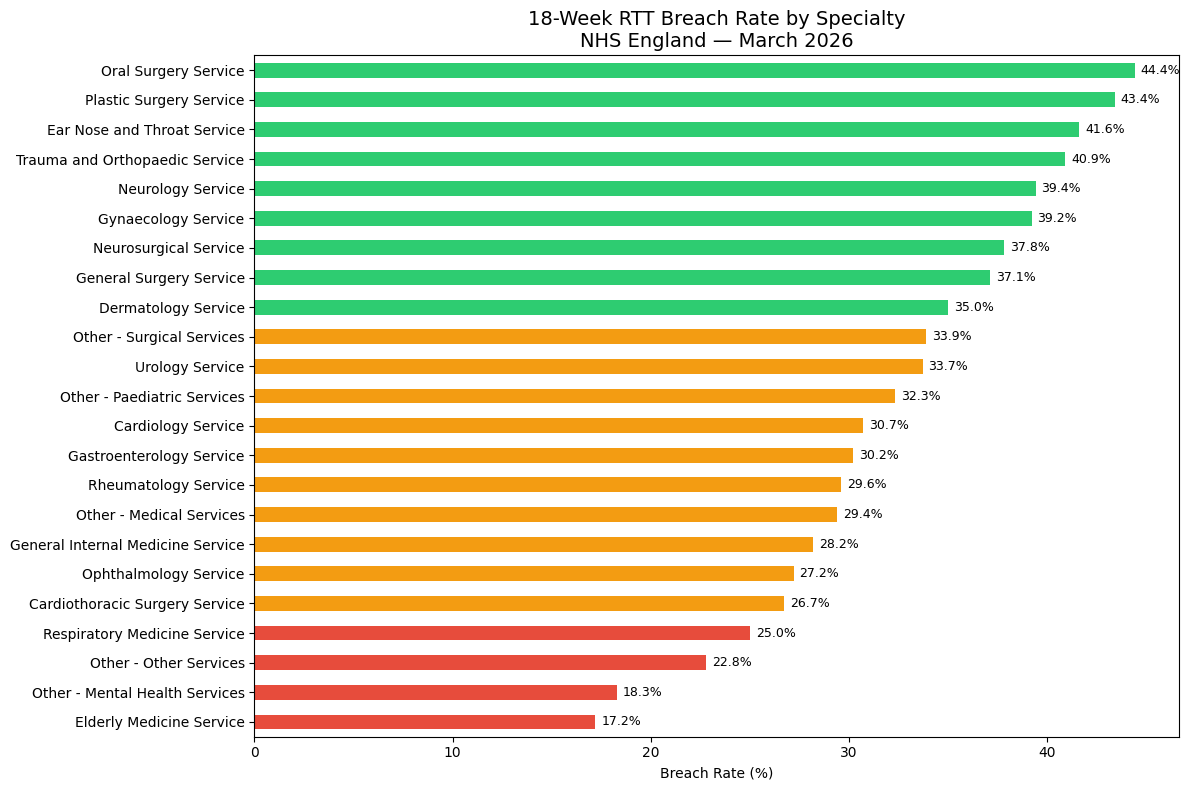

Chart saved!


In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e74c3c' if x > 40 else '#f39c12' if x > 30 else '#2ecc71' 
          for x in specialty_summary['breach_rate_pct']]

specialty_summary.sort_values('breach_rate_pct').plot(
    kind='barh', 
    x='treatment_function_name', 
    y='breach_rate_pct',
    ax=ax,
    color=colors,
    legend=False
)

ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('18-Week RTT Breach Rate by Specialty\nNHS England — March 2026', fontsize=14)
ax.set_xlabel('Breach Rate (%)')
ax.set_ylabel('')

# Add value labels
for i, (val, name) in enumerate(zip(
    specialty_summary.sort_values('breach_rate_pct')['breach_rate_pct'],
    specialty_summary.sort_values('breach_rate_pct')['treatment_function_name']
)):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../docs/specialty_breach_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== LONG WAITERS (52+ weeks) BY SPECIALTY ===
              treatment_function_name  total_waiting  over_52_weeks  over_104_weeks  pct_52_weeks
21     Trauma and Orthopaedic Service       826172.0        18630.0           369.0           2.3
3         Ear Nose and Throat Service       580054.0        12574.0            22.0           2.2
8                 Gynaecology Service       555528.0        10028.0             5.0           1.8
12               Oral Surgery Service       320612.0         7087.0             4.0           2.2
7             General Surgery Service       376693.0         5920.0             7.0           1.6
17          Other - Surgical Services       467771.0         5633.0             9.0           1.2
22                    Urology Service       378188.0         5081.0            31.0           1.3
11              Ophthalmology Service       603966.0         4420.0             4.0           0.7
16        Other - Paediatric Services       316520.0         3900.0     

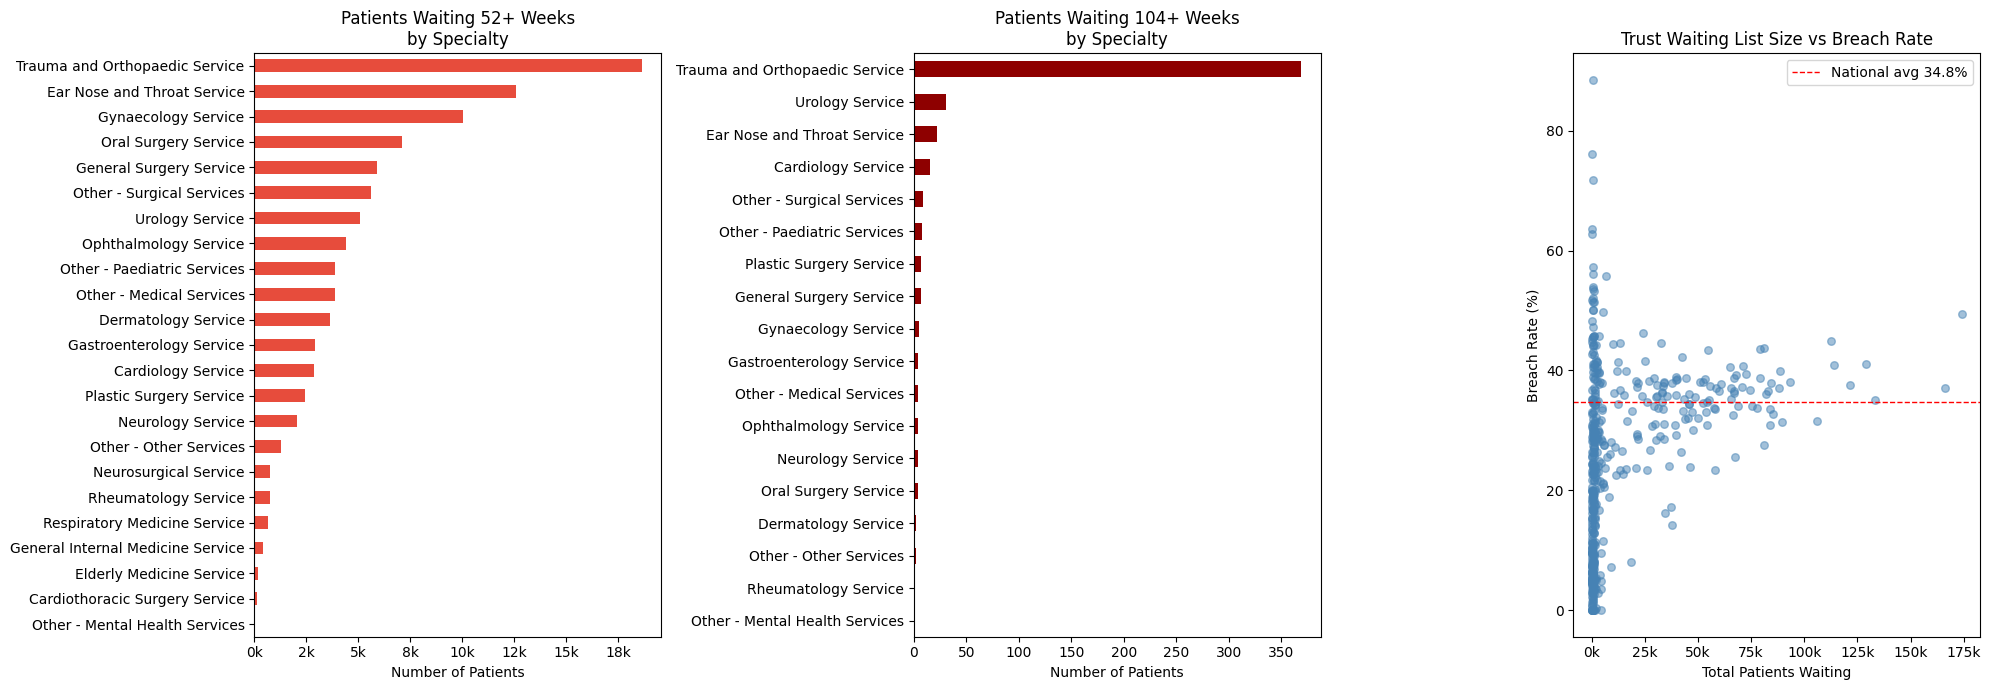

Chart saved!


In [17]:
# ---- LONG WAITERS ANALYSIS ----
print("=== LONG WAITERS (52+ weeks) BY SPECIALTY ===")
long_waiters = specialty_summary[['treatment_function_name', 'total_waiting', 
                                   'over_52_weeks', 'over_104_weeks']].copy()
long_waiters['pct_52_weeks'] = (long_waiters['over_52_weeks'] / long_waiters['total_waiting'] * 100).round(1)
long_waiters = long_waiters.sort_values('over_52_weeks', ascending=False)
print(long_waiters.to_string())

# ---- CHARTS ----
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Chart 1 - Long waiters by specialty
long_waiters.sort_values('over_52_weeks').plot(
    kind='barh', x='treatment_function_name', y='over_52_weeks',
    ax=axes[0], color='#e74c3c', legend=False)
axes[0].set_title('Patients Waiting 52+ Weeks\nby Specialty', fontsize=12)
axes[0].set_xlabel('Number of Patients')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Chart 2 - 104+ week waiters
long_waiters_104 = long_waiters[long_waiters['over_104_weeks'] > 0].sort_values('over_104_weeks')
long_waiters_104.plot(
    kind='barh', x='treatment_function_name', y='over_104_weeks',
    ax=axes[1], color='#8e0000', legend=False)
axes[1].set_title('Patients Waiting 104+ Weeks\nby Specialty', fontsize=12)
axes[1].set_xlabel('Number of Patients')
axes[1].set_ylabel('')

# Chart 3 - Trust scatter: list size vs breach rate
axes[2].scatter(
    trust_summary['total_waiting'],
    trust_summary['breach_rate_pct'],
    alpha=0.5, color='steelblue', s=30)
axes[2].axhline(y=34.8, color='red', linestyle='--', linewidth=1, label='National avg 34.8%')
axes[2].set_title('Trust Waiting List Size vs Breach Rate', fontsize=12)
axes[2].set_xlabel('Total Patients Waiting')
axes[2].set_ylabel('Breach Rate (%)')
axes[2].legend()
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../../docs/long_waiters_and_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [18]:
import sqlite3

# Connect to SQLite database
conn = sqlite3.connect('../../warehouse/nhsflow.db')

# Save all tables to warehouse
curated.to_sql('fact_waiting_list', conn, if_exists='replace', index=False)
trust_summary.to_sql('trust_breach_summary', conn, if_exists='replace', index=False)
specialty_summary.to_sql('specialty_breach_summary', conn, if_exists='replace', index=False)

print("Tables saved to warehouse/nhsflow.db:")
print("- fact_waiting_list")
print("- trust_breach_summary") 
print("- specialty_breach_summary")

# Verify
cursor = conn.cursor()
for table in ['fact_waiting_list', 'trust_breach_summary', 'specialty_breach_summary']:
    cursor.execute(f'SELECT COUNT(*) FROM {table}')
    print(f"  {table}: {cursor.fetchone()[0]} rows")

conn.close()
print("\nDatabase ready for Power BI!")

Tables saved to warehouse/nhsflow.db:
- fact_waiting_list
- trust_breach_summary
- specialty_breach_summary
  fact_waiting_list: 50645 rows
  trust_breach_summary: 477 rows
  specialty_breach_summary: 23 rows

Database ready for Power BI!


In [19]:
import sqlite3
import pandas as pd

# Create one clean summary table for Power BI
powerbi_specialty = specialty_summary.copy()
powerbi_specialty['breach_rate_pct'] = (
    powerbi_specialty['over_18_weeks'] / 
    powerbi_specialty['total_waiting'] * 100
).round(1)
powerbi_specialty['pct_52_weeks'] = (
    powerbi_specialty['over_52_weeks'] / 
    powerbi_specialty['total_waiting'] * 100
).round(1)

powerbi_trust = trust_summary.copy()

# Save clean CSVs
powerbi_specialty.to_csv('../../data/curated/powerbi_specialty.csv', index=False)
powerbi_trust.to_csv('../../data/curated/powerbi_trust.csv', index=False)

print("Saved:")
print("- data/curated/powerbi_specialty.csv")
print("- data/curated/powerbi_trust.csv")
print("\nSpecialty columns:", powerbi_specialty.columns.tolist())
print("Trust columns:", powerbi_trust.columns.tolist())

Saved:
- data/curated/powerbi_specialty.csv
- data/curated/powerbi_trust.csv

Specialty columns: ['treatment_function_name', 'total_waiting', 'over_18_weeks', 'over_52_weeks', 'over_104_weeks', 'breach_rate_pct', 'pct_52_weeks']
Trust columns: ['provider_parent_name', 'provider_org_name', 'total_waiting', 'over_18_weeks', 'over_52_weeks', 'over_104_weeks', 'breach_rate_pct']
